# Standard Learning Curve (Minimal Version)

这个版本只保留 **画标准 learning curve** 需要的流程。

保留内容：
- 路径与超参数
- 数据读取 / 划分
- 训练集与验证集 DataLoader
- 你的 ConvNeXtV2 + ECA + LSMF + UNet++ 模型
- 训练循环
- 标准 learning curve 结果保存与绘图

删除内容：
- calibration
- test set 最终评估
- ROC / PR / confusion matrix
- Grad-CAM
- segmentation 可视化
- RAG / LLM 导出

In [1]:
import os, requests
print("http_proxy =", os.environ.get("http_proxy"))
print("https_proxy =", os.environ.get("https_proxy"))

try:
    r = requests.get("https://huggingface.co", timeout=10)
    print("HF status:", r.status_code)
except Exception as e:
    print("HF failed:", e)

http_proxy = None
https_proxy = None
HF failed: HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7f607408d700>: Failed to establish a new connection: [Errno 101] Network is unreachable'))


In [2]:
import subprocess
import os

result = subprocess.run(
    'bash -c "source /etc/network_turbo && env | grep proxy"',
    shell=True, capture_output=True, text=True
)
for line in result.stdout.splitlines():
    if '=' in line:
        var, value = line.split('=', 1)
        os.environ[var] = value

print(os.environ.get("http_proxy"))
print(os.environ.get("https_proxy"))

http://10.37.1.23:12798
http://10.37.1.23:12798


## 1. Paths & Hyperparameters

In [3]:
import os
import re
import math
import time
import random
from typing import Dict, List

PROJECT_ROOT = "/root/autodl-tmp/myproject"
DATA_ROOT = "/root/autodl-tmp/myproject/data/Datasets/Dataset_1/Chest X-Ray Images with Pneumothorax Masks"

IMG_ROOT  = os.path.join(DATA_ROOT, "png_images")
TRAIN_CSV = os.path.join(DATA_ROOT, "stage_1_train_images.csv")
MASK_ROOT = os.path.join(DATA_ROOT, "png_masks")

OUT_DIR = os.path.join(PROJECT_ROOT, "outputs", "LearningCurve_Baseline_ECA_LSMF")
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE   = 576
BATCH      = 4
LR         = 5e-5
EPOCHS     = 30          # learning-curve usually needs multiple full trainings, so keep practical
VAL_RATIO  = 0.20
SEED       = 42
SAMPLER    = "on"

# learning-curve points
CURVE_FRACTIONS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
MONITOR_METRIC  = "pr_auc"

# optional pretrained backbone
PRETRAIN_BACKBONE = True
PRETRAINED_VARIANT = "convnextv2_tiny.fcmae_ft_in22k_in1k_384"

print("OUT_DIR:", OUT_DIR)
print("IMG_SIZE/BATCH/LR/EPOCHS:", IMG_SIZE, BATCH, LR, EPOCHS)
print("Learning-curve fractions:", CURVE_FRACTIONS)

OUT_DIR: /root/autodl-tmp/myproject/outputs/LearningCurve_Baseline_ECA_LSMF
IMG_SIZE/BATCH/LR/EPOCHS: 576 4 5e-05 30
Learning-curve fractions: [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]


## 2. Imports & Seed

In [4]:
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
import torchvision

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

import timm
import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = (device.type == "cuda")
AMP_DTYPE = torch.float16
print("Using device:", device)

Using device: cuda


## 3. Read CSV, resolve paths, make train/val split

In [5]:
train_df = pd.read_csv(TRAIN_CSV)

def resolve_full_paths(df: pd.DataFrame, img_root: str) -> pd.DataFrame:
    df = df.copy()

    def _resolve(row):
        name = str(row["new_filename"])
        name_png = name if name.lower().endswith(".png") else f"{name}.png"
        p1 = os.path.join(img_root, name_png)
        if os.path.exists(p1):
            return p1
        alt = os.path.join(img_root, f"{row['ImageId']}.png")
        return alt if os.path.exists(alt) else p1

    df["full_path"] = df.apply(_resolve, axis=1)
    return df

train_df = resolve_full_paths(train_df, IMG_ROOT)
missing = (~train_df["full_path"].apply(os.path.exists)).sum()
print("Train rows:", len(train_df), "| Missing images:", missing)

base_train_df, val_df = train_test_split(
    train_df,
    test_size=VAL_RATIO,
    stratify=train_df["has_pneumo"],
    random_state=SEED,
)

base_train_df = base_train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Base train size:", len(base_train_df))
print("Val size:", len(val_df))
print("Base train labels:", base_train_df["has_pneumo"].value_counts().to_dict())
print("Val labels:", val_df["has_pneumo"].value_counts().to_dict())

Train rows: 10675 | Missing images: 0
Base train size: 8540
Val size: 2135
Base train labels: {0: 6637, 1: 1903}
Val labels: {0: 1659, 1: 476}


## 4. Datasets & Transforms

In [6]:
class JointImageMaskTransform:
    def __init__(self, out_size=IMG_SIZE):
        self.out_size = out_size

    def __call__(self, img, mask):
        resize_to = int(self.out_size * 1.1)
        img  = TF.resize(img,  (resize_to, resize_to), interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (resize_to, resize_to), interpolation=InterpolationMode.NEAREST)

        i, j, h, w = torchvision.transforms.RandomResizedCrop.get_params(
            img,
            scale=(0.8, 1.0),
            ratio=(0.9, 1.1)
        )
        img  = TF.resized_crop(img,  i, j, h, w, (self.out_size, self.out_size),
                               interpolation=InterpolationMode.BILINEAR)
        mask = TF.resized_crop(mask, i, j, h, w, (self.out_size, self.out_size),
                               interpolation=InterpolationMode.NEAREST)

        if random.random() < 0.5:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)

        if random.random() < 0.5:
            angle = random.uniform(-7, 7)
            img  = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        if random.random() < 0.5:
            b_factor = 1.0 + random.uniform(-0.15, 0.15)
            c_factor = 1.0 + random.uniform(-0.15, 0.15)
            img = TF.adjust_brightness(img, b_factor)
            img = TF.adjust_contrast(img, c_factor)

        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.5], [0.25])

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()
        return img, mask

class PandasImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_path"]).convert("L")
        if self.transform:
            img = self.transform(img)
        y = int(row["has_pneumo"])
        return img, y

class PandasImageMaskDataset(Dataset):
    def __init__(self, df: pd.DataFrame, mask_root: str, joint_transform: JointImageMaskTransform):
        self.df = df.reset_index(drop=True)
        self.mask_root = mask_root
        self.joint_transform = joint_transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["full_path"]
        img = Image.open(img_path).convert("L")

        basename = os.path.basename(img_path)
        mask_path = os.path.join(self.mask_root, basename)
        if not os.path.exists(mask_path):
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        mask = Image.open(mask_path).convert("L")
        img, mask = self.joint_transform(img, mask)

        y = float(row["has_pneumo"])
        return img, y, mask

train_eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.25]),
])

joint_train_tfms = JointImageMaskTransform(out_size=IMG_SIZE)

def make_weights_for_balancing(df: pd.DataFrame) -> np.ndarray:
    counts = df["has_pneumo"].value_counts().to_dict()
    return df["has_pneumo"].map(lambda y: 1.0 / counts[int(y)]).values.astype(np.float32)

def build_loaders(train_sub_df: pd.DataFrame):
    ds_train = PandasImageMaskDataset(train_sub_df, mask_root=MASK_ROOT, joint_transform=joint_train_tfms)
    ds_train_eval = PandasImageDataset(train_sub_df, transform=train_eval_tfms)
    ds_val = PandasImageDataset(val_df, transform=train_eval_tfms)

    if SAMPLER == "on":
        weights = make_weights_for_balancing(train_sub_df)
        sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
        shuffle = False
    else:
        sampler = None
        shuffle = True

    dl_train = DataLoader(
        ds_train, batch_size=BATCH, sampler=sampler, shuffle=shuffle,
        num_workers=0, pin_memory=(device.type == "cuda")
    )
    dl_train_eval = DataLoader(
        ds_train_eval, batch_size=BATCH, shuffle=False,
        num_workers=0, pin_memory=(device.type == "cuda")
    )
    dl_val = DataLoader(
        ds_val, batch_size=BATCH, shuffle=False,
        num_workers=0, pin_memory=(device.type == "cuda")
    )
    return dl_train, dl_train_eval, dl_val

## 5. Model Definition

In [7]:
def drop_path(x, drop_prob: float = 0.0, training: bool = False):
    if drop_prob == 0.0 or not training:
        return x
    keep_prob = 1.0 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    return x * random_tensor / keep_prob

class DropPath(nn.Module):
    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

class GRN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(dim))
        self.beta = nn.Parameter(torch.zeros(dim))
    def forward(self, x):
        gx = torch.norm(x, p=2, dim=(1, 2), keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * nx) + self.beta + x

class LayerNorm2d(nn.Module):
    def __init__(self, num_channels, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))
        self.eps = eps
    def forward(self, x):
        u = x.mean(1, keepdim=True)
        s = (x - u).pow(2).mean(1, keepdim=True)
        x = (x - u) / torch.sqrt(s + self.eps)
        return self.weight[:, None, None] * x + self.bias[:, None, None]

class ECALayer(nn.Module):
    def __init__(self, channel, k_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2))
        y = y.transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y.expand_as(x)

class GeM(nn.Module):
    def __init__(self, p=3.0, eps=1e-6, trainable=True, relu_before=True):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p) if trainable else torch.tensor([p], dtype=torch.float32)
        self.eps = eps
        self.relu_before = relu_before
    def forward(self, x):
        if self.relu_before:
            x = F.relu(x)
        p = torch.clamp(self.p, min=self.eps)
        x = x.clamp(min=self.eps).pow(p[..., None, None])
        x = F.adaptive_avg_pool2d(x, 1).pow(1.0 / p[..., None, None])
        return x.flatten(1)

class LSMFHead(nn.Module):
    def __init__(self, in_ch_x3=384, in_ch_x4=768, fuse_ch=256, n_classes=1, gem_p=3.0, gn_groups=8):
        super().__init__()
        self.proj_x3 = nn.Sequential(
            nn.Conv2d(in_ch_x3, fuse_ch, kernel_size=1, bias=False),
            nn.GroupNorm(gn_groups, fuse_ch),
            nn.GELU(),
        )
        self.proj_x4 = nn.Sequential(
            nn.Conv2d(in_ch_x4, fuse_ch, kernel_size=1, bias=False),
            nn.GroupNorm(gn_groups, fuse_ch),
            nn.GELU(),
        )
        self.gate = nn.Sequential(
            nn.Conv2d(fuse_ch * 2, fuse_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(gn_groups, fuse_ch),
            nn.GELU(),
            nn.Conv2d(fuse_ch, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.refine = nn.Sequential(
            nn.Conv2d(fuse_ch, fuse_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(gn_groups, fuse_ch),
            nn.GELU(),
        )
        self.gem = GeM(p=gem_p, eps=1e-6, trainable=True, relu_before=True)
        self.norm = nn.LayerNorm(fuse_ch, eps=1e-6)
        self.fc = nn.Linear(fuse_ch, n_classes)

    def forward(self, x3, x4, feat_dict=None):
        x4_up = F.interpolate(x4, size=x3.shape[-2:], mode="bilinear", align_corners=False)
        x3_p = self.proj_x3(x3)
        x4_p = self.proj_x4(x4_up)
        gate = self.gate(torch.cat([x3_p, x4_p], dim=1))
        fused = gate * x3_p + (1.0 - gate) * x4_p
        fused = self.refine(fused)
        pooled = self.gem(fused)
        pooled = self.norm(pooled)
        logits = self.fc(pooled).squeeze(1)

        if feat_dict is not None:
            feat_dict["lsmf_vec"] = pooled.detach()
        return logits

class ConvNeXtV2Block(nn.Module):
    def __init__(self, dim: int, mlp_ratio: float = 4.0, drop_path: float = 0.0, layer_scale_init_value: float = 0.0):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = nn.LayerNorm(dim, eps=1e-6)
        hidden_dim = int(dim * mlp_ratio)
        self.pwconv1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.grn = GRN(hidden_dim)
        self.pwconv2 = nn.Linear(hidden_dim, dim)
        if layer_scale_init_value > 0:
            self.gamma = nn.Parameter(layer_scale_init_value * torch.ones(dim))
        else:
            self.gamma = None
        self.drop_path = DropPath(drop_path) if drop_path > 0.0 else nn.Identity()

    def forward(self, x):
        shortcut = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma.view(1, 1, 1, -1) * x
        x = x.permute(0, 3, 1, 2)
        x = shortcut + self.drop_path(x)
        return x

class UpBlockUNetPP(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.upsample = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv1 = nn.Conv2d(in_ch + skip_ch, out_ch, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.act   = nn.ReLU(inplace=True)

    def forward(self, x, skips=None):
        x = self.upsample(x)
        skips = [] if skips is None else skips
        cat_list = [x]
        for s in skips:
            if s is None:
                continue
            if s.shape[-2:] != x.shape[-2:]:
                s = F.interpolate(s, size=x.shape[-2:], mode="bilinear", align_corners=False)
            cat_list.append(s)
        x = torch.cat(cat_list, dim=1)
        x = self.act(self.bn1(self.conv1(x)))
        x = self.act(self.bn2(self.conv2(x)))
        return x

class ConvNeXtV2Tiny(nn.Module):
    def __init__(self, in_chans=3, num_classes=1000, drop_path_rate=0.0, layer_scale_init_value=0.0):
        super().__init__()
        depths = [3, 3, 9, 3]
        dims = [96, 192, 384, 768]

        self.downsample_layers = nn.ModuleList()
        self.stages = nn.ModuleList()

        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm2d(dims[0]),
        )
        self.downsample_layers.append(stem)

        total_blocks = sum(depths)
        dpr_values = torch.linspace(0, drop_path_rate, total_blocks).tolist()
        block_idx = 0

        for stage_idx in range(4):
            depth = depths[stage_idx]
            dim = dims[stage_idx]

            if stage_idx > 0:
                down = nn.Sequential(
                    LayerNorm2d(dims[stage_idx - 1]),
                    nn.Conv2d(dims[stage_idx - 1], dim, kernel_size=2, stride=2),
                )
                self.downsample_layers.append(down)

            blocks = []
            for i in range(depth):
                blocks.append(
                    ConvNeXtV2Block(
                        dim=dim,
                        mlp_ratio=4.0,
                        drop_path=dpr_values[block_idx + i],
                        layer_scale_init_value=layer_scale_init_value,
                    )
                )
            block_idx += depth
            self.stages.append(nn.Sequential(*blocks))

        self.norm_head = nn.LayerNorm(dims[-1], eps=1e-6)
        self.head = nn.Linear(dims[-1], num_classes) if num_classes > 0 else nn.Identity()

    def forward_features(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        x = x.mean(dim=[2, 3])
        x = self.norm_head(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x

class ConvNeXtV2TinyScratch(nn.Module):
    def __init__(self, in_chans=1, n_classes=1, drop_path_rate=0.1, use_seg_guided=False, use_lsmf=True, lsmf_fuse_ch=256):
        super().__init__()

        self.backbone = ConvNeXtV2Tiny(
            in_chans=in_chans,
            num_classes=n_classes,
            drop_path_rate=drop_path_rate,
            layer_scale_init_value=0.0,
        )

        dims = [96, 192, 384, 768]
        c1, c2, c3, c4 = dims
        last_dim = c4

        self.eca4 = ECALayer(last_dim, k_size=3)

        self.use_seg_guided = use_seg_guided
        self.seg_guided_scale = 0.5
        self.use_lsmf = use_lsmf

        self.gem = GeM(p=3.0, eps=1e-6, trainable=True, relu_before=True)
        self.cls_head = nn.Linear(last_dim, n_classes)

        self.lsmf_head = LSMFHead(
            in_ch_x3=c3,
            in_ch_x4=c4,
            fuse_ch=lsmf_fuse_ch,
            n_classes=n_classes,
            gem_p=3.0,
            gn_groups=8,
        )

        self.last_feats = {}

        self.up_2_1 = UpBlockUNetPP(in_ch=768, skip_ch=384, out_ch=384)
        self.up_1_1 = UpBlockUNetPP(in_ch=384, skip_ch=192, out_ch=192)
        self.up_0_1 = UpBlockUNetPP(in_ch=192, skip_ch=96,  out_ch=96)
        self.up_1_2 = UpBlockUNetPP(in_ch=384, skip_ch=192 + 192, out_ch=192)
        self.up_0_2 = UpBlockUNetPP(in_ch=192, skip_ch=96 + 96,   out_ch=96)
        self.up_0_3 = UpBlockUNetPP(in_ch=192, skip_ch=96 + 96 + 96, out_ch=96)

        self.up_half = UpBlockUNetPP(in_ch=96, skip_ch=0, out_ch=max(96 // 2, 32))
        self.seg_head = nn.Conv2d(max(96 // 2, 32), 1, kernel_size=1)

    def forward_backbone_pyramid(self, x):
        feats = []
        for i in range(4):
            x = self.backbone.downsample_layers[i](x)
            x = self.backbone.stages[i](x)
            if i == 3:
                x = self.eca4(x)
            feats.append(x)
        return feats

    def forward(self, x):
        self.last_feats = {}
        x1, x2, x3, x4 = self.forward_backbone_pyramid(x)

        x0_0 = x1
        x1_0 = x2
        x2_0 = x3
        x3_0 = x4

        x2_1 = self.up_2_1(x3_0, [x2_0])
        x1_1 = self.up_1_1(x2_0, [x1_0])
        x0_1 = self.up_0_1(x1_0, [x0_0])

        x1_2 = self.up_1_2(x2_1, [x1_0, x1_1])
        x0_2 = self.up_0_2(x1_1, [x0_0, x0_1])

        x0_3 = self.up_0_3(x1_2, [x0_0, x0_1, x0_2])

        d0 = self.up_half(x0_3, [])
        seg_logits = self.seg_head(d0)
        seg_logits = F.interpolate(seg_logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

        x4_for_cls = x4
        if self.use_seg_guided:
            seg_prob = torch.sigmoid(seg_logits)
            seg_down = F.adaptive_avg_pool2d(seg_prob, output_size=x4.shape[-2:])
            x4_for_cls = x4 * (1.0 + self.seg_guided_scale * seg_down)

        if self.use_lsmf:
            cls_logits = self.lsmf_head(x3, x4_for_cls, feat_dict=self.last_feats)
        else:
            gap = self.gem(x4_for_cls)
            gap = self.backbone.norm_head(gap)
            cls_logits = self.cls_head(gap).squeeze(1)

        return cls_logits, seg_logits

def _remap_timm_convnextv2_to_custom_backbone(timm_state):
    mapped = {}
    for k, v in timm_state.items():
        if k.startswith("head.fc.") or k.startswith("head.pre_logits.") or k.startswith("head.drop"):
            continue
        if k.startswith("stem."):
            new_k = k.replace("stem.", "downsample_layers.0.", 1)
        elif k.startswith("head.norm."):
            new_k = k.replace("head.norm.", "norm_head.", 1)
        elif re.match(r"^stages\.\d+\.downsample\.", k):
            m = re.match(r"^stages\.(\d+)\.downsample\.(\d+)\.(.*)$", k)
            stage_idx = int(m.group(1))
            sub_idx = int(m.group(2))
            rest = m.group(3)
            new_k = f"downsample_layers.{stage_idx}.{sub_idx}.{rest}"
        elif re.match(r"^stages\.\d+\.blocks\.\d+\.", k):
            m = re.match(r"^stages\.(\d+)\.blocks\.(\d+)\.(.*)$", k)
            stage_idx = int(m.group(1))
            block_idx = int(m.group(2))
            rest = m.group(3)
            rest = rest.replace("conv_dw", "dwconv")
            rest = rest.replace("mlp.fc1", "pwconv1")
            rest = rest.replace("mlp.fc2", "pwconv2")
            rest = rest.replace("mlp.grn.weight", "grn.gamma")
            rest = rest.replace("mlp.grn.bias",   "grn.beta")
            new_k = f"stages.{stage_idx}.{block_idx}.{rest}"
        else:
            continue
        mapped[new_k] = v
    return mapped

def load_pretrained_backbone_from_timm(model, variant=PRETRAINED_VARIANT):
    print(f"[Pretrain] Loading timm weights: {variant}")
    timm_model = timm.create_model(
        variant,
        pretrained=True,
        in_chans=1,
        num_classes=1000,
    )
    timm_state = timm_model.state_dict()
    mapped_state = _remap_timm_convnextv2_to_custom_backbone(timm_state)

    backbone_state = model.backbone.state_dict()
    loadable = {}
    for k, v in mapped_state.items():
        if k in backbone_state and backbone_state[k].shape == v.shape:
            loadable[k] = v

    missing, unexpected = model.backbone.load_state_dict(loadable, strict=False)
    print(f"[Pretrain] Loaded tensors: {len(loadable)} | Missing: {len(missing)} | Unexpected: {len(unexpected)}")
    return model

def build_model():
    model = ConvNeXtV2TinyScratch(
        in_chans=1,
        n_classes=1,
        drop_path_rate=0.1,
        use_seg_guided=False,
        use_lsmf=True,
        lsmf_fuse_ch=256,
    ).to(device)

    if PRETRAIN_BACKBONE:
        try:
            model = load_pretrained_backbone_from_timm(model, PRETRAINED_VARIANT)
        except Exception as e:
            print("[Pretrain] skipped due to error:", e)

    return model

## 6. Losses, Optimizer, Evaluation

In [8]:
LAMBDA_SEG = 0.3

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, smooth=1e-6, pos_only=True):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
        self.pos_only = pos_only

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        targets = targets.float()

        B = probs.size(0)
        probs_flat = probs.view(B, -1)
        targets_flat = targets.view(B, -1)

        if self.pos_only:
            pos_mask = (targets_flat.sum(dim=1) > 0)
            if pos_mask.any():
                probs_flat = probs_flat[pos_mask]
                targets_flat = targets_flat[pos_mask]
            else:
                return logits.new_tensor(0.0)

        TP = (probs_flat * targets_flat).sum(dim=1)
        FP = (probs_flat * (1.0 - targets_flat)).sum(dim=1)
        FN = ((1.0 - probs_flat) * targets_flat).sum(dim=1)
        tversky = (TP + self.smooth) / (TP + self.alpha * FP + self.beta * FN + self.smooth)
        return (1.0 - tversky).mean()

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        if logits.dim() > targets.dim():
            targets = targets.view_as(logits)
        targets = targets.float()

        prob = torch.sigmoid(logits)
        pt = prob * targets + (1 - prob) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - pt).pow(self.gamma)

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        loss = focal_weight * bce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

def build_adamw_with_wd_groups(model, lr, weight_decay=5e-4):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim < 2 or name.endswith(".bias") or ("norm" in name.lower()):
            no_decay.append(p)
        else:
            decay.append(p)

    optimizer = torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=lr
    )
    return optimizer

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, preds, scores = [], [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        out = model(xb)
        logits = out[0] if isinstance(out, tuple) else out
        probs = torch.sigmoid(logits)
        pred = (probs >= 0.5).long()

        ys.extend(yb.cpu().numpy().tolist())
        preds.extend(pred.cpu().numpy().tolist())
        scores.extend(probs.cpu().numpy().tolist())

    y_true = np.array(ys)
    y_pred = np.array(preds)
    y_score = np.array(scores)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    try:
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        spec = tn / (tn + fp + 1e-8)
    except Exception:
        spec = float("nan")

    try:
        roc = roc_auc_score(y_true, y_score)
    except Exception:
        roc = float("nan")

    try:
        pr = average_precision_score(y_true, y_score)
    except Exception:
        pr = float("nan")

    return {
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "spec": spec,
        "roc_auc": roc,
        "pr_auc": pr,
    }

## 7. Standard Learning Curve

In [9]:
from tqdm.auto import tqdm

MONITOR    = MONITOR_METRIC
PATIENCE   = 6
MIN_EPOCHS = 8
DELTA      = 1e-4

def sample_stratified_fraction(df: pd.DataFrame, frac: float, seed: int) -> pd.DataFrame:
    if frac >= 0.999:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    parts = []
    for label, group in df.groupby("has_pneumo"):
        n_take = max(1, int(round(len(group) * frac)))
        n_take = min(n_take, len(group))
        parts.append(group.sample(n=n_take, random_state=seed))
    out = pd.concat(parts, ignore_index=True)
    out = out.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def train_one_curve_point(train_sub_df: pd.DataFrame, frac: float, seed_offset: int = 0) -> Dict:
    local_seed = SEED + seed_offset
    set_seed(local_seed)

    dl_train, dl_train_eval, dl_val = build_loaders(train_sub_df)

    model = build_model()

    criterion_cls = BinaryFocalLoss(alpha=0.5, gamma=2.0)
    criterion_segF = BinaryFocalLoss(alpha=0.5, gamma=2.0)
    criterion_segT = TverskyLoss(alpha=0.3, beta=0.7, pos_only=True)

    optimizer = build_adamw_with_wd_groups(model, lr=LR, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

    best_score = -float("inf")
    best_epoch = 0
    epochs_bad = 0
    best_state = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        nb = 0

        pbar = tqdm(dl_train, leave=False, desc=f"frac={frac:.2f} epoch={epoch}/{EPOCHS}")
        for xb, yb, mb in pbar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True).float()
            mb = mb.to(device, non_blocking=True).float()

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=AMP_ENABLED):
                cls_logits, seg_logits = model(xb)
                cls_loss = criterion_cls(cls_logits, yb)
                seg_loss = criterion_segF(seg_logits, mb) + criterion_segT(seg_logits, mb)
                loss = cls_loss + LAMBDA_SEG * seg_loss

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            running += loss.item()
            nb += 1
            pbar.set_postfix(loss=f"{running / max(nb, 1):.4f}")

        scheduler.step()

        val_metrics = evaluate(model, dl_val, device)
        score = float(val_metrics[MONITOR])
        improved = score > (best_score + DELTA)

        if improved:
            best_score = score
            best_epoch = epoch
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            epochs_bad = 0
        else:
            epochs_bad += 1

        print(
            f"[frac={frac:.2f}] epoch {epoch:02d}/{EPOCHS} | "
            f"val_pr={val_metrics['pr_auc']:.4f} val_roc={val_metrics['roc_auc']:.4f} "
            f"best_{MONITOR}={best_score:.4f} @ {best_epoch}"
        )

        if epoch >= MIN_EPOCHS and epochs_bad >= PATIENCE:
            print(f"[EarlyStop] frac={frac:.2f} stop at epoch {epoch}, best epoch {best_epoch}")
            break

    if best_state is None:
        best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    train_metrics = evaluate(model, dl_train_eval, device)
    val_metrics = evaluate(model, dl_val, device)

    result = {
        "fraction": frac,
        "n_train": int(len(train_sub_df)),
        "pos_train": int((train_sub_df["has_pneumo"] == 1).sum()),
        "neg_train": int((train_sub_df["has_pneumo"] == 0).sum()),
        "best_epoch": int(best_epoch),
        "train_acc": float(train_metrics["acc"]),
        "train_f1": float(train_metrics["f1"]),
        "train_roc_auc": float(train_metrics["roc_auc"]),
        "train_pr_auc": float(train_metrics["pr_auc"]),
        "val_acc": float(val_metrics["acc"]),
        "val_f1": float(val_metrics["f1"]),
        "val_roc_auc": float(val_metrics["roc_auc"]),
        "val_pr_auc": float(val_metrics["pr_auc"]),
    }
    return result

results = []
for frac in CURVE_FRACTIONS:
    train_sub_df = sample_stratified_fraction(base_train_df, frac=frac, seed=SEED)
    print("\n" + "=" * 90)
    print(f"Start curve point: frac={frac:.2f} | samples={len(train_sub_df)}")
    print("label dist:", train_sub_df["has_pneumo"].value_counts().to_dict())

    point_result = train_one_curve_point(train_sub_df, frac=frac)
    results.append(point_result)

results_df = pd.DataFrame(results).sort_values("n_train").reset_index(drop=True)
csv_path = os.path.join(OUT_DIR, "learning_curve_results.csv")
results_df.to_csv(csv_path, index=False)

print("\nSaved results to:", csv_path)
print(results_df)


Start curve point: frac=0.10 | samples=854
label dist: {0: 664, 1: 190}
[Pretrain] Loading timm weights: convnextv2_tiny.fcmae_ft_in22k_in1k_384
[Pretrain] Loaded tensors: 198 | Missing: 2 | Unexpected: 0


frac=0.10 epoch=1/30:   0%|          | 0/214 [00:00<?, ?it/s]

[frac=0.10] epoch 01/30 | val_pr=0.5662 val_roc=0.8015 best_pr_auc=0.5662 @ 1


frac=0.10 epoch=2/30:   0%|          | 0/214 [00:00<?, ?it/s]

[frac=0.10] epoch 02/30 | val_pr=0.6469 val_roc=0.8399 best_pr_auc=0.6469 @ 2


...

[frac=1.00] epoch 11/30 | val_pr=0.8747 val_roc=0.9543 best_pr_auc=0.8882 @ 7


frac=1.00 epoch=12/30:   0%|          | 0/2135 [00:00<?, ?it/s]

[frac=1.00] epoch 12/30 | val_pr=0.8798 val_roc=0.9559 best_pr_auc=0.8882 @ 7


frac=1.00 epoch=13/30:   0%|          | 0/2135 [00:00<?, ?it/s]

[frac=1.00] epoch 13/30 | val_pr=0.8685 val_roc=0.9535 best_pr_auc=0.8882 @ 7
[EarlyStop] frac=1.00 stop at epoch 13, best epoch 7

Saved results to: /root/autodl-tmp/myproject/outputs/LearningCurve_Baseline_ECA_LSMF/learning_curve_results.csv
   fraction  n_train  pos_train  neg_train  best_epoch  train_acc  train_f1  \
0       0.1      854        190        664          21   0.989461  0.976864   
1       0.2     1708        381       1327          22   0.911593  0.832780   
2       0.4     3416        761       2655          22   0.944379  0.885680   
3       0.6     5124       1142       3982          14   0.965457  0.927607   
4       0.8     6832       1522       5310          13   0.976874  0.950283   
5       1.0     8540       1903       6637           7   0.946721  0.887682   

   train_roc_auc  train_pr_auc   val_acc    val_f1  val_roc_auc  val_pr_auc  
0       0.999802      0.999312  0.861358  0.705765     0.883791    0.736388  
1       0.987707      0.958197  0.852927  0.72

## 8. Plot Standard Learning Curve

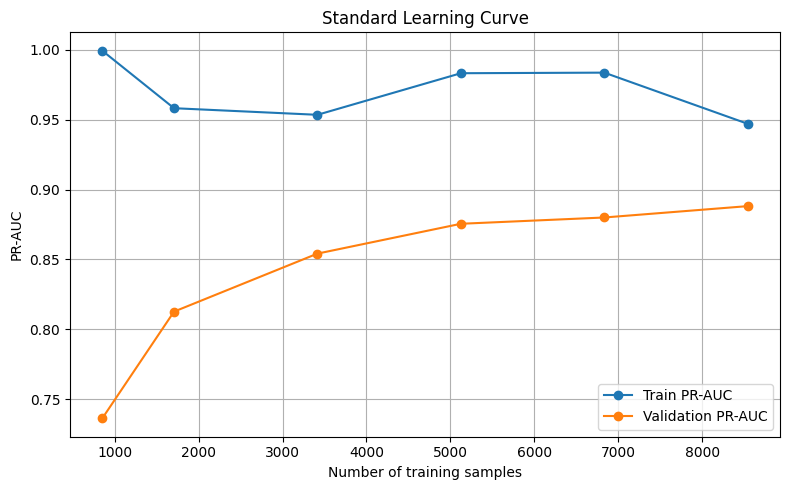

Saved figure to: /root/autodl-tmp/myproject/outputs/LearningCurve_Baseline_ECA_LSMF/standard_learning_curve_pr_auc.png


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["n_train"], results_df["train_pr_auc"], marker="o", label="Train PR-AUC")
plt.plot(results_df["n_train"], results_df["val_pr_auc"], marker="o", label="Validation PR-AUC")
plt.xlabel("Number of training samples")
plt.ylabel("PR-AUC")
plt.title("Standard Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "standard_learning_curve_pr_auc.png")
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved figure to:", fig_path)